In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from tabulate import tabulate as tab

import generate_synthetic_data as gsd


# Read Data

In [40]:
def normalize_to_peak_amplitude(pulses):
    return pulses / np.max(pulses, axis=1, keepdims=True)


def get_data(noise_level, Case = 'Case10', pathToDatasets = '../synthetic_data/Synthetic_Datasets', validation=False):
    if validation:
        data = np.load(f"{pathToDatasets}/synthetic_validation_{Case}_480k_noise_{noise_level}.npz")
    else:
        data = np.load(f"{pathToDatasets}/synthetic_training_{Case}_120k_noise_{noise_level}.npz")
    return data["X"], data["y"]

In [41]:
pathToDatasets = 'Synthetic_Datasets_v01'
Case = 'Case10'
noise_level = 0.001

train_x, train_y = get_data(noise_level, Case = Case, pathToDatasets = pathToDatasets, validation=False)
eval_x,  eval_y  = get_data(noise_level, Case = Case, pathToDatasets = pathToDatasets, validation=True)
eval_x_norm = normalize_to_peak_amplitude(eval_x)

train_x.shape, eval_x.shape, eval_x_norm.shape

((120000, 296), (360000, 296), (360000, 296))

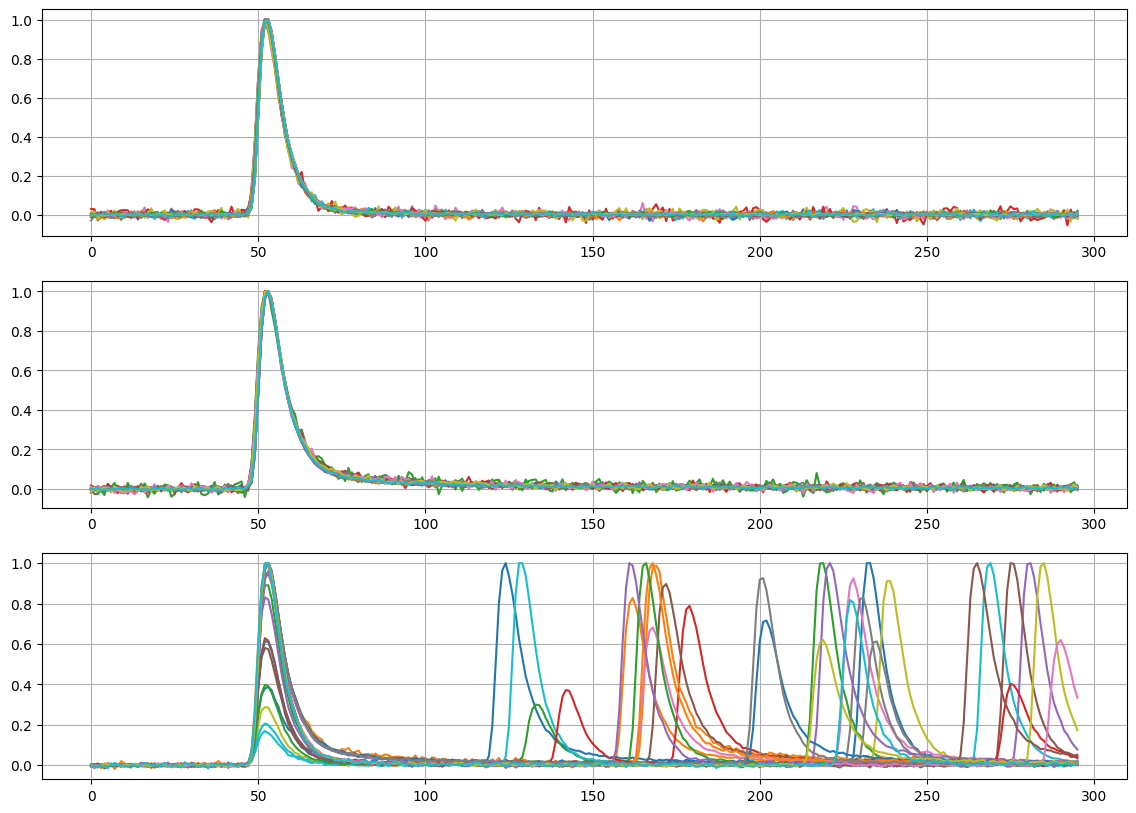

In [42]:
_, axs = plt.subplots(3, 1, figsize=(14, 10))
for i in range(0, 3):
    for p in train_x[train_y==i][:30]:
        axs[i].plot(p)
    axs[i].grid()


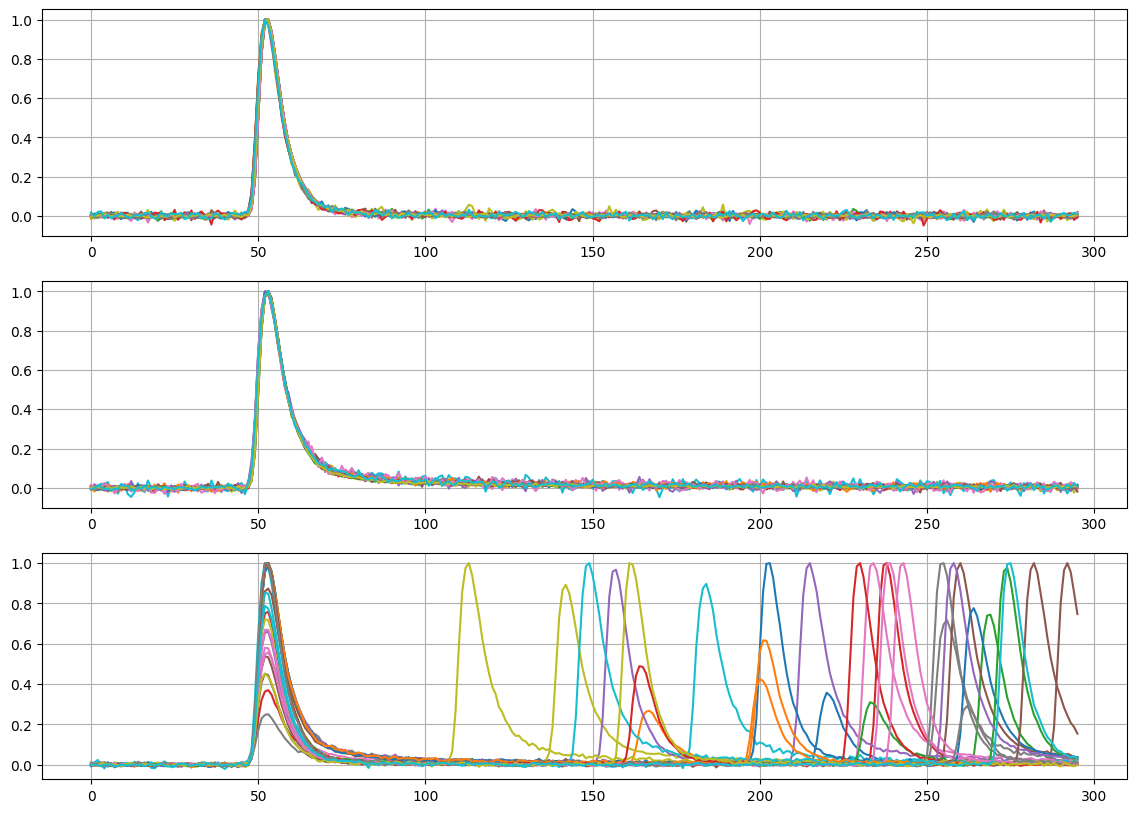

In [44]:
_, axs = plt.subplots(3, 1, figsize=(14, 10))
ev = eval_x_norm
for i in range(0, 3):
    for p in ev[eval_y==i][:30]:
        axs[i].plot(p)
    axs[i].grid()

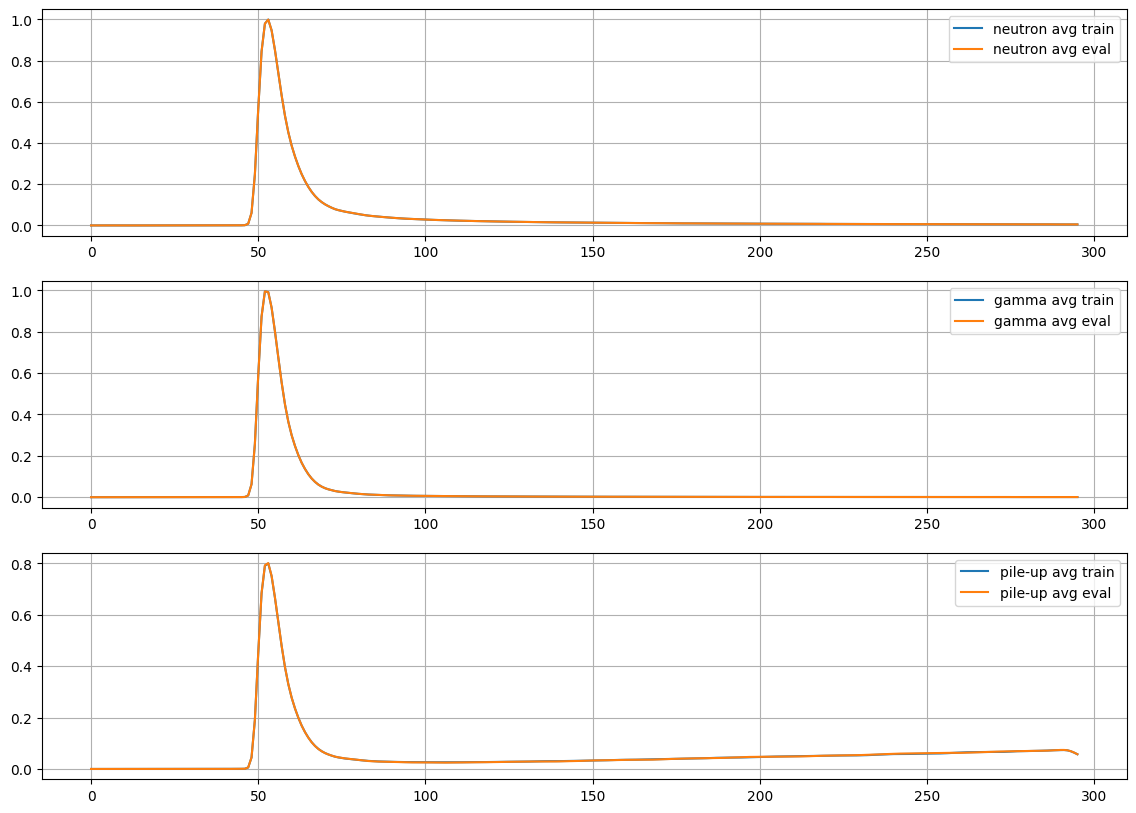

In [52]:
avg_train_n = np.mean(train_x[train_y==1], axis=0)
avg_train_g = np.mean(train_x[train_y==0], axis=0)
avg_train_p = np.mean(train_x[train_y==2], axis=0)

avg_eval_n_norm = np.mean(eval_x_norm[eval_y==1], axis=0)
avg_eval_g_norm = np.mean(eval_x_norm[eval_y==0], axis=0)
avg_eval_p_norm = np.mean(eval_x_norm[eval_y==2], axis=0)

_, axs = plt.subplots(3, 1, figsize=(14, 10))
axs[0].plot(avg_train_n, label='neutron avg train')
axs[0].plot(avg_eval_n_norm, label='neutron avg eval')
axs[1].plot(avg_train_g, label='gamma avg train')
axs[1].plot(avg_eval_g_norm, label='gamma avg eval')
axs[2].plot(avg_train_p, label='pile-up avg train')
axs[2].plot(avg_eval_p_norm, label='pile-up avg eval')
for i in range(0, 3):
    axs[i].grid()
    axs[i].legend();

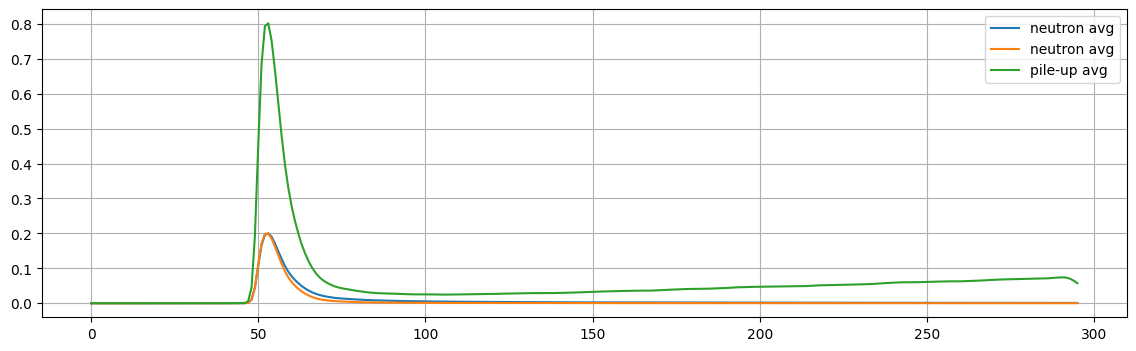

In [54]:
avg_eval_n = np.mean(eval_x[eval_y==1], axis=0)
avg_eval_g = np.mean(eval_x[eval_y==0], axis=0)
avg_eval_p = np.mean(eval_x[eval_y==2], axis=0)

_, ax = plt.subplots(1, 1, figsize=(14, 4))
ax.plot(avg_eval_n, label='neutron avg')
ax.plot(avg_eval_g, label='neutron avg')
ax.plot(avg_eval_p,  label='pile-up avg')
ax.grid()
ax.legend();